In [84]:
!pip install torch # installation

In [85]:
import torch  # import library
# tensor is the funcdamental data structure like list or array
mylist = [[1,2,3],[4,5,7]]
mytensor = torch.tensor(mylist)
print(mytensor)
print(mytensor.shape,mytensor.dtype)  # dimension and datatype

tensor([[1, 2, 3],
        [4, 5, 7]])
torch.Size([2, 3]) torch.int64


In [86]:
x = torch.tensor([[1.5, 2.3, 3.7], [4.1, 5.8, 6.2]])
# x = torch.tensor([[1.5, 2.3], [3.4, 4.5]], dtype=torch.float32)
# x = torch.tensor([[True, False], [False, True]])
# STRINGS NOT ALLOWED IN PYTORCH    x = torch.tensor([["Alice", "Bob"], ["Charlie", "David"]])
# mixed datatypes also not allowed
print(x.shape)   # torch.Size([2, 2])
print(x.dtype)   # torch.float32
print(x.ndim)    # 2
print(x.device)  # cpu

torch.Size([2, 3])
torch.float32
2
cpu


In [87]:
# TENSOR OPERATIONS

mytensor1 = torch.tensor([[1111,2345,2343],[34567,655,788888]])
mytensor2 = torch.tensor([[987, 654, 321],[111, 222, 333]])
# mytensor3 = torch.tensor([[987, 654, 321],[111, 222]])
print("addition",mytensor1+mytensor2)
# print("addition",mytensor1+mytensor3)  # error shape must be same
print("subtraction",mytensor1-mytensor2)
print("element wise multiply",mytensor1*mytensor2)
#  print("matrix multiplication",mytensor1@mytensor2)   RuntimeError: mat1 and mat2 shapes cannot be multiplied (2x3 and 2x3)


addition tensor([[  2098,   2999,   2664],
        [ 34678,    877, 789221]])
subtraction tensor([[   124,   1691,   2022],
        [ 34456,    433, 788555]])
element wise multiply tensor([[  1096557,   1533630,    752103],
        [  3836937,    145410, 262699704]])


In [88]:
# first neural network
# fully connected, equivalent to a linear model
import torch.nn as nn

# input neurons = features, o/p neurons = classes
input_tensor = torch.tensor([[0.3471,0.4547,-0.2356]])

linear_layer=nn.Linear(in_features=3,out_features=2)
output = linear_layer(input_tensor)
print(output)

print(linear_layer.weight)
print(linear_layer.bias)

tensor([[ 0.1057, -0.1955]], grad_fn=<AddmmBackward0>)
Parameter containing:
tensor([[ 0.0080,  0.0843,  0.4183],
        [-0.1109,  0.5099, -0.2052]], requires_grad=True)
Parameter containing:
tensor([ 0.1632, -0.4372], requires_grad=True)


In [89]:
# network with three linear models
model = nn.Sequential(
    nn.Linear(10,18),
    nn.Linear(18,20),
    nn.Linear(20,5)
)
print(model)

Sequential(
  (0): Linear(in_features=10, out_features=18, bias=True)
  (1): Linear(in_features=18, out_features=20, bias=True)
  (2): Linear(in_features=20, out_features=5, bias=True)
)


In [90]:
"""
Layers are made of neurons
fully connected when each neuron links to all neurons in the previous layer

a neuron in a linear layer performs a linear operation using all neurons from the previous layer

"""

'\nLayers are made of neurons\nfully connected when each neuron links to all neurons in the previous layer\n\na neuron in a linear layer performs a linear operation using all neurons from the previous layer\n\n'

In [91]:
import torch
import torch.nn as nn

input_tensor = torch.rand(30,10)  # tensor 300x10

model = nn.Sequential(
    nn.Linear(in_features=10,out_features=30),
    nn.Linear(in_features=30,out_features=50),
    nn.Linear(in_features=50,out_features=3)
)

output = model(input_tensor)
print(output)

# Print weights and bias of Layer 1
print(model[0].weight)
print(model[0].bias)

# Print weights and bias of Layer 2
print(model[1].weight)
print(model[1].bias)

# Print weights and bias of Layer 3
print(model[2].weight)
print(model[2].bias)

# more hidden layers = more parameters = higher model capacity
total = 0
for parameter in model.parameters():
  total += parameter.numel()
print(total)   # to print number of parameters

tensor([[ 0.0417, -0.0962, -0.0531],
        [ 0.0178, -0.0744, -0.1737],
        [ 0.0352, -0.0947, -0.1438],
        [ 0.0450, -0.0723, -0.1005],
        [ 0.0422, -0.0369, -0.1662],
        [-0.0226, -0.0726, -0.0010],
        [ 0.0553, -0.0843, -0.2048],
        [ 0.0289, -0.0510, -0.1716],
        [-0.0643, -0.0381, -0.1324],
        [-0.0155, -0.0938, -0.1587],
        [-0.0534, -0.0675, -0.0578],
        [-0.0316, -0.0743, -0.1999],
        [ 0.0380, -0.0553, -0.1618],
        [ 0.0875, -0.0639, -0.2184],
        [ 0.0158, -0.1230, -0.0787],
        [ 0.0269, -0.0816, -0.0399],
        [ 0.0076, -0.0628, -0.0629],
        [-0.0118, -0.0232, -0.0562],
        [ 0.1123, -0.1238, -0.1060],
        [-0.0171, -0.0330, -0.0694],
        [-0.0506, -0.0030, -0.1999],
        [-0.0081, -0.0363, -0.0219],
        [-0.0170, -0.0751, -0.0943],
        [ 0.0808, -0.0240, -0.0651],
        [ 0.0614, -0.0908, -0.0936],
        [ 0.0761, -0.0471, -0.0744],
        [ 0.0104, -0.0735, -0.0293],
 

In [92]:
# ACTIVATION FUNCTIONS ADD NON-LINEARITY TO THE NETWORK
# SIGMOID FOR BINARY CLASSIFICATION AND SOFTMAX FOR MULTI-CLASS CLASSIFICATION
# WITH NON-LINEARITY MORE COMPLEX RELATIONSHIPS CAN BE LEARNT BY THE NETWORK
# PRE-ACTIVATION OUTPUT PASSED TO THE ACTIVATION FUNCTION

In [93]:
# SIGMOID IN PYTORCH
import torch, torch.nn as nn

tensor = torch.tensor([[5]])
sigmoid = nn.Sigmoid()
print(sigmoid(tensor))   # nn.Sigmoid(torch.tensor([[5]]))

# sigmoid as layer
model = nn.Sequential(
    nn.Linear(6,4),   # FIRST LINEAR LAYER
    nn.Linear(4,1),   # Second linear layer
    nn.Sigmoid()  #activation
)

# sigmoid as last layer of linear network is equivalent to logistic regression

tensor([[0.9933]])


In [94]:
# SOFTMAX FUNCTION
import torch, torch.nn as nn
tensor = torch.tensor([[4.3,6.1,7.9]])
# softmax takes n-dimensional input and generates output of the same shape
# each output element is a probability distribution between zero and one , sum of all elements == 1
prob = nn.Softmax(dim=-1)  # softmax to last dimension
print(prob(tensor))

tensor([[0.0229, 0.1386, 0.8385]])


# FOWARD PASS
INPUT DATA FLOWS THROUGH LAYERS

CALCULATION PERFORMED AT EACH LAYER

FINAL LAYER GENERATES OUTPUT BASED ON WEIGHTS AND BIASES

used for training and making predictions

---- possible outputs ---

binary classification, multi-class classification , regressions



In [95]:
# BINARY CLASSIFICATION - FORWARD PASS

input_tensor = torch.tensor([
    [2.35, 1.20, 0.85, 3.10, 2.75, 1.50],
    [0.95, 2.80, 1.65, 2.10, 0.45, 3.25],
    [1.75, 0.60, 2.95, 1.40, 2.20, 0.90],
    [3.05, 2.10, 1.30, 0.75, 1.85, 2.60],
    [1.15, 2.45, 3.20, 1.95, 0.80, 2.35]
], dtype=torch.float32)

# consider it as 5 animals with 6 features

model = nn.Sequential(
    nn.Linear(in_features=6,out_features=4),
    nn.Linear(in_features=4,out_features=1),
    nn.Sigmoid()
)

print(model(input_tensor))  # output 5 prob btw 0 and 1
# threshold can be 0.5, CLASS=1 >= 0.5 IS MAMMAL AND CLASS=0 IS NOT MAMMAL < 0.5

tensor([[0.2835],
        [0.3758],
        [0.3480],
        [0.3117],
        [0.3866]], grad_fn=<SigmoidBackward0>)


In [96]:
#  MULTI-CLASS CLASSIFICATION forward pass
# class 1- mammal, class 2 is bird, class 3 is reptile

n_classes = 3
model1 = nn.Sequential(
    nn.Linear(6,4), #first linear layer
    nn.Linear(4,n_classes) , # second linear layer
    nn.Softmax(dim=-1)
)

print(model1(input_tensor))

# each row sums to one
# predicted label = class with highest probability

tensor([[0.5642, 0.1323, 0.3035],
        [0.3601, 0.3310, 0.3088],
        [0.5433, 0.1524, 0.3044],
        [0.4581, 0.1273, 0.4146],
        [0.4281, 0.2925, 0.2795]], grad_fn=<SoftmaxBackward0>)


In [97]:
# regression forward pass
model2 = nn.Sequential(
    nn.Linear(6,4),
    nn.Linear(4,1)
)

print(model2(input_tensor))

tensor([[ 0.3210],
        [-0.9810],
        [-0.0039],
        [-0.2659],
        [-0.8138]], grad_fn=<AddmmBackward0>)


LOSS FUNCTION - HOW GOOD MODEL IS DURING MODEL

TAKES MODEL PREDICTION AND GROUND TRUTH

OUTPUTS A FLOAT


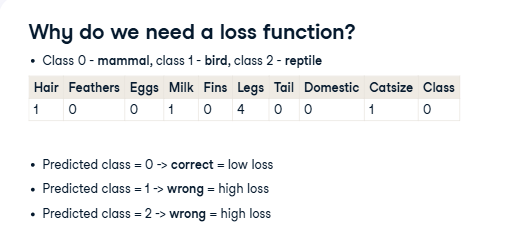

One-hot encoding is a data preprocessing technique that converts categorical text or labels into a binary numerical format by creating a separate column or vector element for each unique category, assigning a 1 for presence and 0 for absence.How It WorksNew Columns: Each unique value in a category becomes its own independent column.Binary Values: A value of 1 is placed in the column matching the current item, and 0 is placed in all other columns.No False Order: It stops a computer from thinking one category value is mathematically "greater" or "better" than another (which happens if you use simple numbers like 1, 2, 3).Why It Is UsedModel Needs: Machine learning algorithms and neural networks require numbers, not words, to run math equations.Fair Treatment: It treats every category as totally separate and equal.DownsidesHigh Size: If you have thousands of unique words or categories, your data table gets very wide and large.Lots of Zeros: It creates sparse data filled with many zeros, which can slow down training.

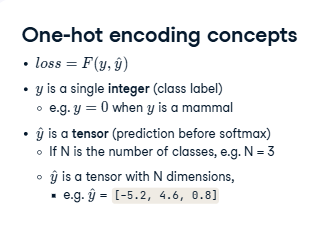

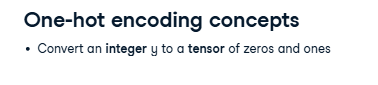

In [98]:
# transforming lables with one-hot encoding

"""
torch.tensor(0) means:

Create a PyTorch tensor that contains the single value 0.

It is not a list, not an array, and not a vector. It is a scalar tensor (a 0-dimensional tensor).

"""
import torch
import torch.nn.functional as f
print(f.one_hot(torch.tensor(0),num_classes=3))

print(f.one_hot(torch.tensor(1),num_classes=3))

print(f.one_hot(torch.tensor(2),num_classes=3))

print(f.one_hot(torch.tensor(2),num_classes=4))

tensor([1, 0, 0])
tensor([0, 1, 0])
tensor([0, 0, 1])
tensor([0, 0, 1, 0])


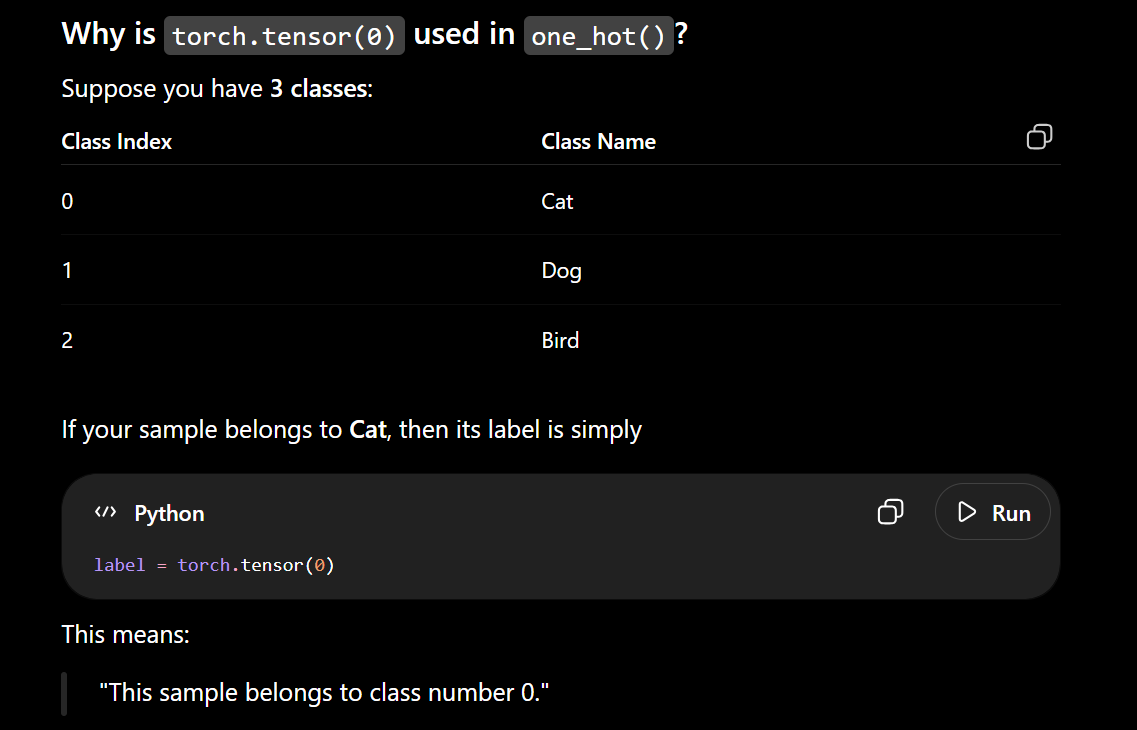

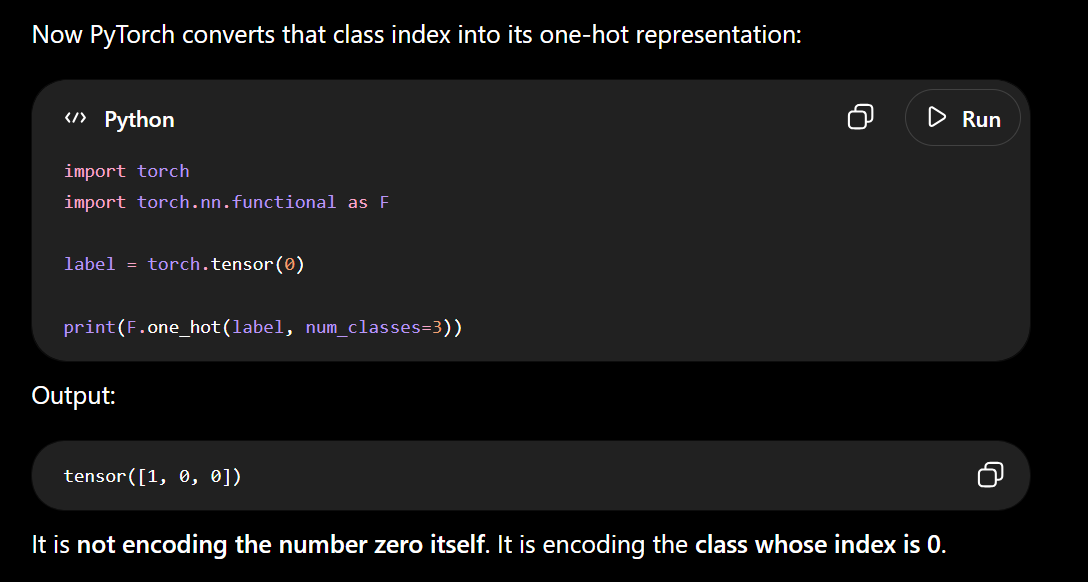

# cross entropy loss
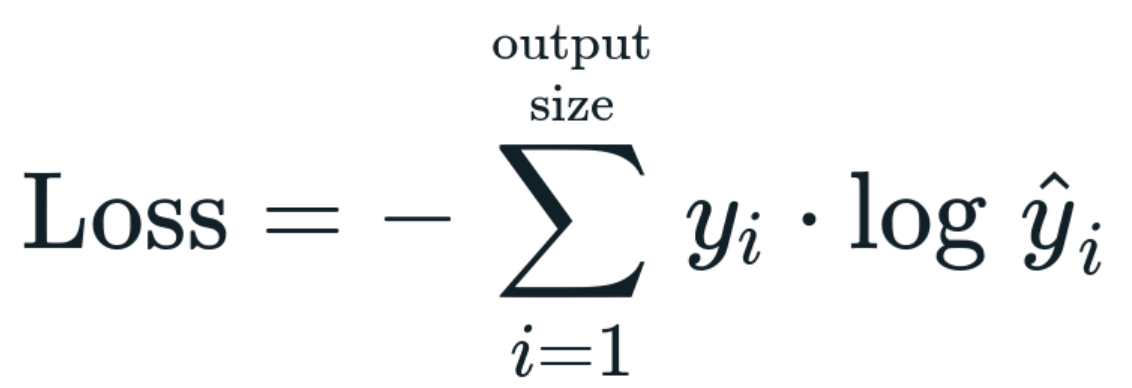

In [99]:
from torch.nn import CrossEntropyLoss

scores=torch.tensor([-5.2,4.5,6.77])
one_shot_target = torch.tensor([1,0,0])
criterion = CrossEntropyLoss()
print(criterion(scores.double(),one_shot_target.double()))

tensor(12.0683, dtype=torch.float64)


Loss function takes:

• scores - model predictions before the final softmax function

• one_hot_target - one hot encoded ground truth label

Loss function outputs:

• loss - a single float

In [100]:
import torch
import torch.nn.functional as F
from torch.nn import CrossEntropyLoss

y = [2]
scores = torch.tensor([[0.1, 6.0, -2.0, 3.2]])

# Create a one-hot encoded vector of the label y
one_hot_label = F.one_hot(torch.tensor(y), num_classes=4)
print(one_hot_label)

# Create the cross entropy loss function
criterion = CrossEntropyLoss()

# Calculate the cross entropy loss
loss = criterion(scores.double(), one_hot_label.double())
print(loss)

tensor([[0, 0, 1, 0]])
tensor(8.0619, dtype=torch.float64)


In [101]:
import torch
import torch.nn.functional as f
labels = torch.tensor([2, 0, 3, 1])
F.one_hot(labels, num_classes=4)

tensor([[0, 0, 1, 0],
        [1, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 1, 0, 0]])

GRADIENTS ( DERIVATIVES ) TO MINIMIZE THE LOSS
DERIVATIVE REPRESENTS THE SLOPE OF CURVE

STEEP SLOPE - DERIVATIVE IS HIGH
GENTLER SLOPES - DERIVATIVE IS LOW

VALLEY FLOOR - DERIVATIVE IS ZERO


A convex function is a continuous, bowl-shaped curve where a straight line drawn between any two points on the graph stays on or above the curve. A non-convex function curves up and down with multiple peaks and valleys, meaning a line between two points can dip below the graph

Optimization and Minima
Convex: Has only one single lowest point (the global minimum). Any local minimum is also the global minimum.Non-Convex: Contains multiple local minima and saddle points, meaning an optimization algorithm can get trapped in a shallow dip instead of the true lowest point

CONNECTING DERIVATIVES AND MODEL TRAINING - COMPUTE THE LOSS IN THE FORWARD PASS DURING TRAINING
WEIGHTS AND BIASES ARE RANDOM

USING GRADIENTS WE UPDATE WEIGHTS AND BIASES AND RETRAIN USING BACK PROPAGATION



# BACKPROPAGATION CONCEPTS

consider a network made of three layers

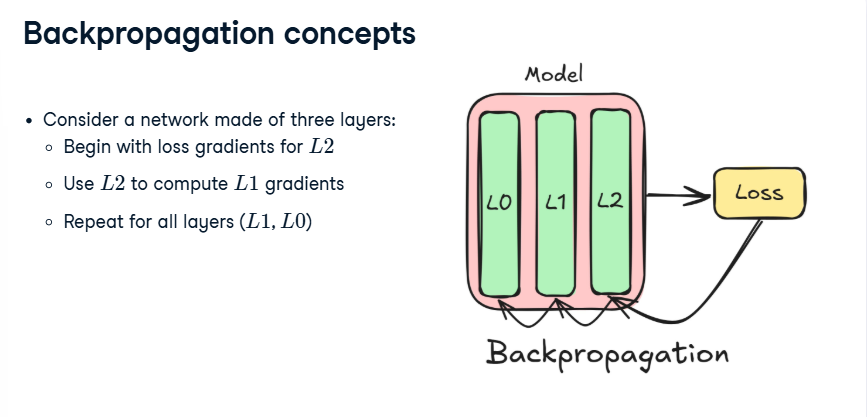

In [102]:
import torch
import torch.nn as nn

sample=torch.randn(1,16)
target=torch.tensor([1])

model=nn.Sequential(nn.Linear(16,8),
                    nn.Linear(8,4),
                    nn.Linear(4,2))

prediction=model(sample)
criterion=nn.CrossEntropyLoss()
loss=criterion(prediction,target)
loss.backward()

print(model[0].weight)
print(model[0].bias)

print(model[1].weight)
print(model[1].bias)

print(model[2].weight)
print(model[2].bias)

print(model[0].weight.grad)
print(model[0].bias.grad)

print(model[1].weight.grad)
print(model[1].bias.grad)

print(model[2].weight.grad)
print(model[2].bias.grad)

Parameter containing:
tensor([[-0.1759,  0.0471,  0.0558,  0.1905, -0.0021, -0.0675, -0.1457, -0.0892,
          0.2163,  0.0774,  0.1542, -0.0412, -0.2001, -0.0142, -0.0300, -0.0532],
        [-0.2226, -0.1920, -0.2289,  0.2261, -0.0475,  0.0142,  0.2151,  0.2363,
          0.1025,  0.0122,  0.1726,  0.2486, -0.1830,  0.0926,  0.1056,  0.2224],
        [-0.1338,  0.0063,  0.2116, -0.0241,  0.1103, -0.1075, -0.1603, -0.2058,
         -0.0855, -0.0489, -0.0866, -0.1467, -0.0224, -0.2347, -0.1883,  0.2031],
        [ 0.0840,  0.0878, -0.2195, -0.2239,  0.0166, -0.1340,  0.0896, -0.1728,
         -0.1923, -0.2380, -0.0074,  0.0145,  0.0386, -0.2321, -0.2034,  0.0473],
        [-0.1600, -0.0573, -0.1986, -0.1973, -0.0961, -0.1157, -0.1865, -0.0875,
         -0.0717,  0.1386, -0.1679,  0.1873, -0.1410,  0.0187,  0.1362, -0.1870],
        [-0.1748,  0.1853, -0.1530,  0.1824, -0.0694, -0.2392, -0.0806, -0.1797,
          0.2157,  0.2030, -0.1082,  0.0237, -0.1065,  0.2106, -0.2307,  0.1909],


In [103]:
# update model parameters manually

lr = 0.001 # learning rate
weight = model[0].weight
weight_grad = model[0].weight.grad

weight = weight - lr * weight_grad

bias = model[0].bias
bias_grad = model[0].bias.grad
bias = bias - lr * bias_grad

# access each layer gradient
# multiply by the learning rate
# subtract this product from the weight
# lr is a tunable parameter

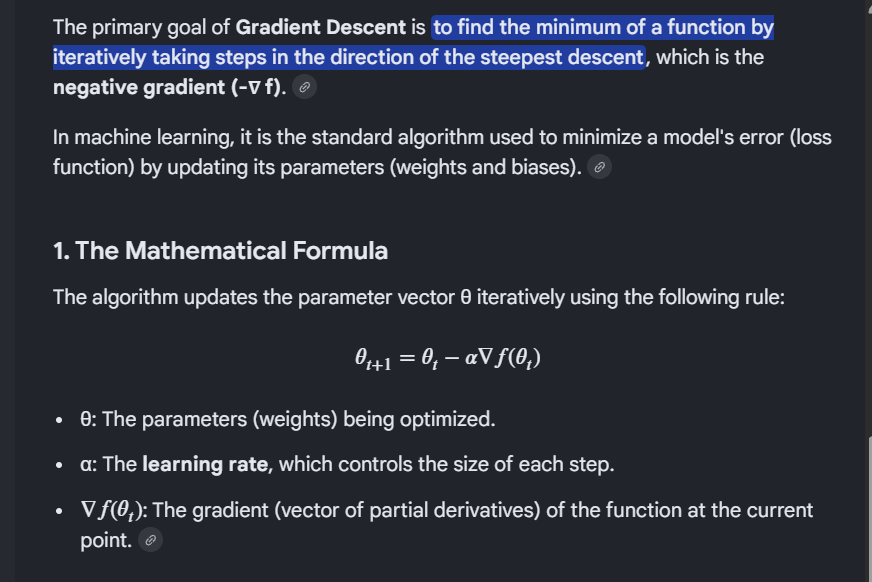

 Step-by-Step Mechanism

 Initialize: Start with a random guess or arbitrary values for the parameters (θ₀).
 Calculate Gradient: Compute the partial derivatives of the function with respect to each parameter at the current point to determine the slope.
 Update Parameters: Multiply the gradient by the learning rate (α) and subtract this value from the current parameters to move downhill.

 Repeat: Continue steps 2 and 3 until the gradient is close to zero (convergence) or a maximum number of iterations is reached.

 3. Behavior on Convex vs. Non-Convex FunctionsConvex Functions: Gradient descent is guaranteed to find the global minimum because there are no local traps or valleys to get stuck in.Non-Convex Functions: The algorithm can easily get trapped in a local minimum or a flat saddle point, missing the true lowest point (global minimum) depending heavily on where the initialization started.4. Tuning the Learning Rate (α)Too Small: The steps are tiny, making the algorithm incredibly slow to converge.Too Large: The algorithm can overshoot the minimum, bounce back and forth, and potentially diverge completely.

In [104]:
# gradient descent for non-convex functions

# pytorch simplifies this with optimizers
# stochastic graident descent sgd

import torch.optim as optim

# create the optimizer
optimizer = optim.SGD(model.parameters(),lr=0.001)
optimizer.step()

In [105]:
import torch
import torch.nn as nn
import torch.optim as optim

sample=torch.randn(1,4)
target=torch.tensor([1])
model=nn.Linear(4,2)
optimizer=optim.SGD(model.parameters(),lr=0.01)
criterion=nn.CrossEntropyLoss()
prediction=model(sample)

loss=criterion(prediction,target)
optimizer.zero_grad()  # reset gradients for all parameters before new computation
loss.backward()   # compute gradient and store in parameter.grad
optimizer.step()

print(prediction)
print(loss)

print(model.weight)
print(model.bias)

# typical training loop
"""
for epoch in range(epochs):

    prediction=model(sample)

    loss=criterion(prediction,target)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

"""

tensor([[ 1.0970, -0.5966]], grad_fn=<AddmmBackward0>)
tensor(1.8624, grad_fn=<NllLossBackward0>)
Parameter containing:
tensor([[-0.1195,  0.3847,  0.4004,  0.2863],
        [-0.2146, -0.3572, -0.2312,  0.2015]], requires_grad=True)
Parameter containing:
tensor([ 0.4012, -0.4667], requires_grad=True)


'\nfor epoch in range(epochs):\n\n    prediction=model(sample)\n\n    loss=criterion(prediction,target)\n\n    optimizer.zero_grad()\n\n    loss.backward()\n\n    optimizer.step()\n\n'

# TRAINING OUR NEURAL NETWORK


In [106]:
import pandas as pd
import numpy as np

animals=pd.DataFrame({
    "animal_name":["sparrow","eagle","cat","dog","lizard"],
    "hair":[0,0,1,1,0],
    "feathers":[1,1,0,0,0],
    "eggs":[1,1,0,0,1],
    "milk":[0,0,1,1,0],
    "predator":[0,1,1,0,1],
    "legs":[2,2,4,4,4],
    "tail":[1,1,1,1,1],
    "type":[0,0,1,1,2]
})

animals

# type categories bird(0), mammal(1), reptile(2)

,animal_name,hair,feathers,eggs,milk,predator,legs,tail,type
0,sparrow,0,1,1,0,0,2,1,0
1,eagle,0,1,1,0,1,2,1,0
2,cat,1,0,0,1,1,4,1,1
3,dog,1,0,0,1,0,4,1,1
4,lizard,0,0,1,0,1,4,1,2


In [107]:
# define input features
features = animals.iloc[:,1:-1]
x = features.to_numpy()    # convert tot a numpy array
print(x)
# iloc[row_selection,column_selection]
# : → Select all rows.
#  1:-1 → Select columns starting from index 1 up to (but not including) the last column.

[[0 1 1 0 0 2 1]
 [0 1 1 0 1 2 1]
 [1 0 0 1 1 4 1]
 [1 0 0 1 0 4 1]
 [0 0 1 0 1 4 1]]


In [108]:
# defining target values
target = animals.iloc[:,-1]
y = target.to_numpy()
print(y)

[0 0 1 1 2]


In [109]:
import torch
from torch.utils.data import TensorDataset

# instantiate dataset class
dataset = TensorDataset(torch.tensor(x),torch.tensor(y))

#access an individual sample
input_sample, label_sample = dataset[0]
print(f"input sample: {input_sample}")
print(f"label sample: {label_sample}")


input sample: tensor([0, 1, 1, 0, 0, 2, 1])
label sample: 0


In [110]:
from torch.utils.data import DataLoader
batch_size = 2 # sample size
shuffle = True # randomizes the data order at each epoch
# it helps to improve model generalization
# one epoch is a full pass through the training data loader
# generalization: model performs well with unseen data

# create a dataloader
dataloader = DataLoader(dataset,batch_size=batch_size,shuffle=shuffle)

# iterate over the dataloader
for batch_inputs,batch_labels in dataloader:
  print(f"batch_inputs: {batch_inputs}")
  print(f"batch_labels: {batch_labels}")



batch_inputs: tensor([[1, 0, 0, 1, 1, 4, 1],
        [0, 1, 1, 0, 0, 2, 1]])
batch_labels: tensor([1, 0])
batch_inputs: tensor([[0, 0, 1, 0, 1, 4, 1],
        [0, 1, 1, 0, 1, 2, 1]])
batch_labels: tensor([2, 0])
batch_inputs: tensor([[1, 0, 0, 1, 0, 4, 1]])
batch_labels: tensor([1])


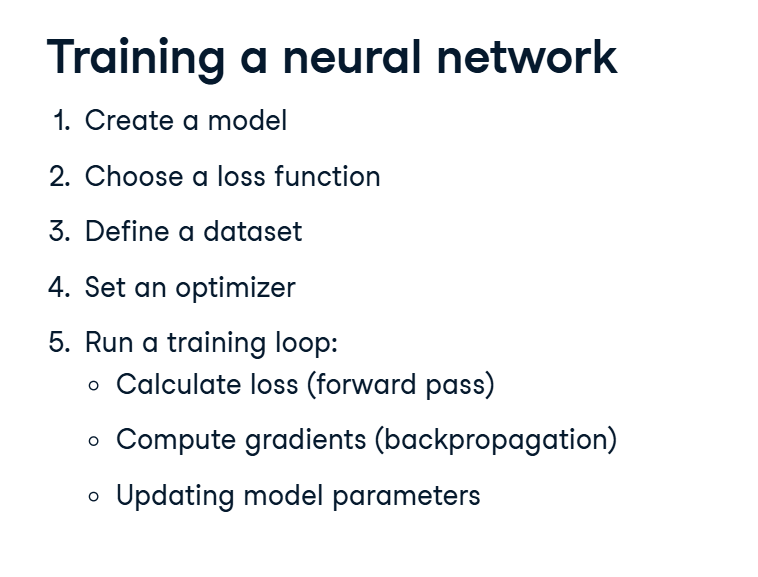

In [111]:
def mean_squared_error(prediction,target):
  return (np.mean((prediction-target)**2))
# in pytorch
# criterion = nn.MSELoss()
# loss = criterion(prediction,target)

In [112]:
import pandas as pd
import numpy as np

dataset=pd.DataFrame({
    "experience_level":[0,1,2,1,2],
    "employment_type":[0,0,0,0,0],
    "remote_ratio":[0.5,1.0,0.0,1.0,1.0],
    "company_size":[1,2,1,0,1],
    "salary_in_usd":[0.036,0.133,0.234,0.076,0.170]
})

print(dataset)

features=dataset.iloc[:,:-1].to_numpy()
target=dataset.iloc[:,-1].to_numpy()
print(features)
print(target)

   experience_level  employment_type  remote_ratio  company_size  \
0                 0                0           0.5             1   
1                 1                0           1.0             2   
2                 2                0           0.0             1   
3                 1                0           1.0             0   
4                 2                0           1.0             1   

   salary_in_usd  
0          0.036  
1          0.133  
2          0.234  
3          0.076  
4          0.170  
[[0.  0.  0.5 1. ]
 [1.  0.  1.  2. ]
 [2.  0.  0.  1. ]
 [1.  0.  1.  0. ]
 [2.  0.  1.  1. ]]
[0.036 0.133 0.234 0.076 0.17 ]


In [113]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(torch.tensor(features).float(),torch.tensor(target).float())
dataloader = DataLoader(dataset,batch_size=4,shuffle=True)

# create model
model = nn.Sequential(nn.Linear(in_features=4,out_features=2), nn.Linear(in_features=2,out_features=1))

# create loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(),lr=0.001)  # lr is learning rate

number_of_epochs = 10

# training loop of our neural network
for epoch in range(number_of_epochs):
  for data in dataloader:
    optimizer.zero_grad() # set all graidents to zero
    feature,target = data # get both from data loader
    prediction = model(feature) # forward pass
    # compute loss and gradients
    loss = criterion(prediction,target)
    loss.backward()
    optimizer.step() #update parameters


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([4])) that is different to the input size (torch.Size([4, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


The vanishing gradient is a training issue in deep neural networks where gradients shrink close to zero in earlier layers, preventing weights from updating and stopping the network from learning. Key causes include the chain rule multiplying small activation derivatives and excessive network depth

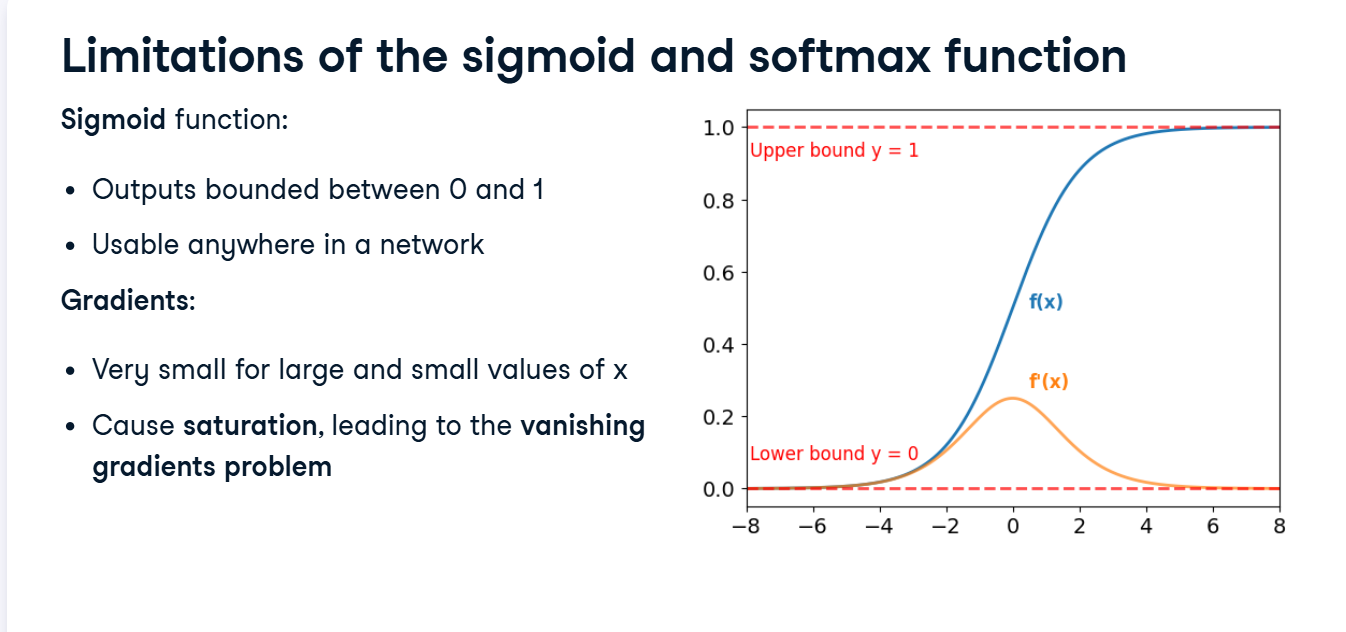


How Saturation Happens Extreme logits: Large positive or negative input values (logits) fed into the exponential function \(e^{z}\) create massive gaps between classes.Probability polarization: One output probability approaches 1 while the rest approach 0.Flat derivative zones: The Jacobian matrix derivative of softmax becomes near-zero when probabilities hit these extremes, meaning changes in inputs yield no change in outputs

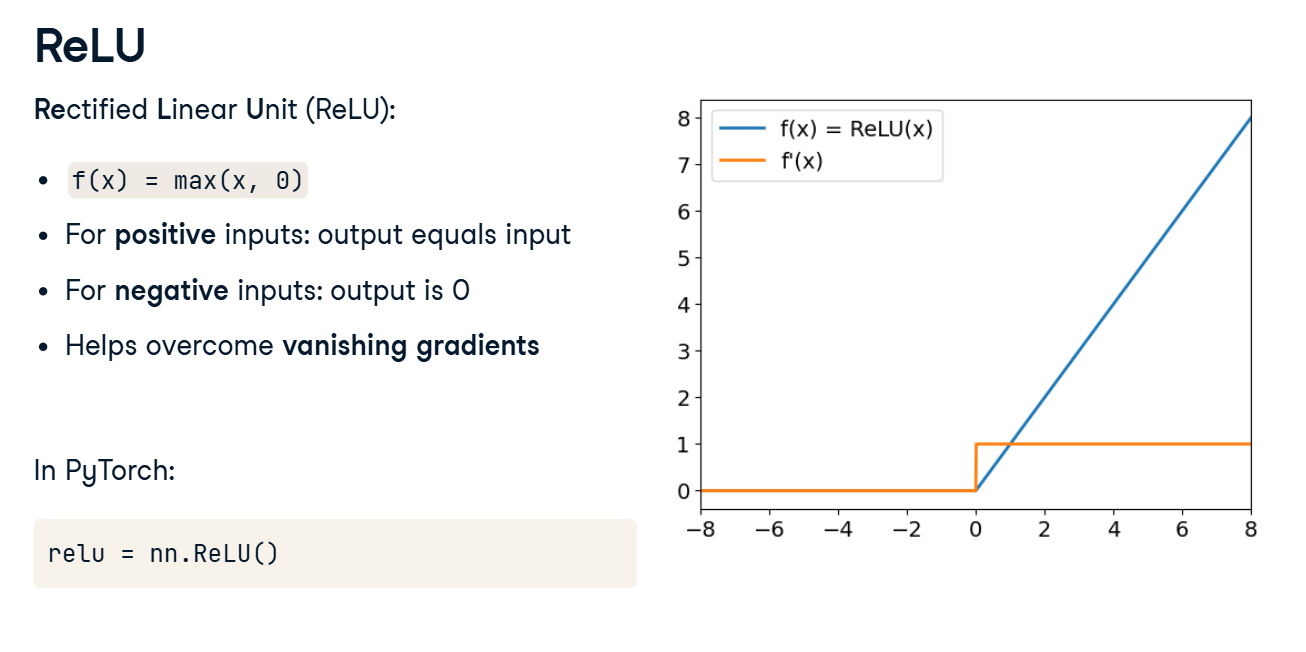

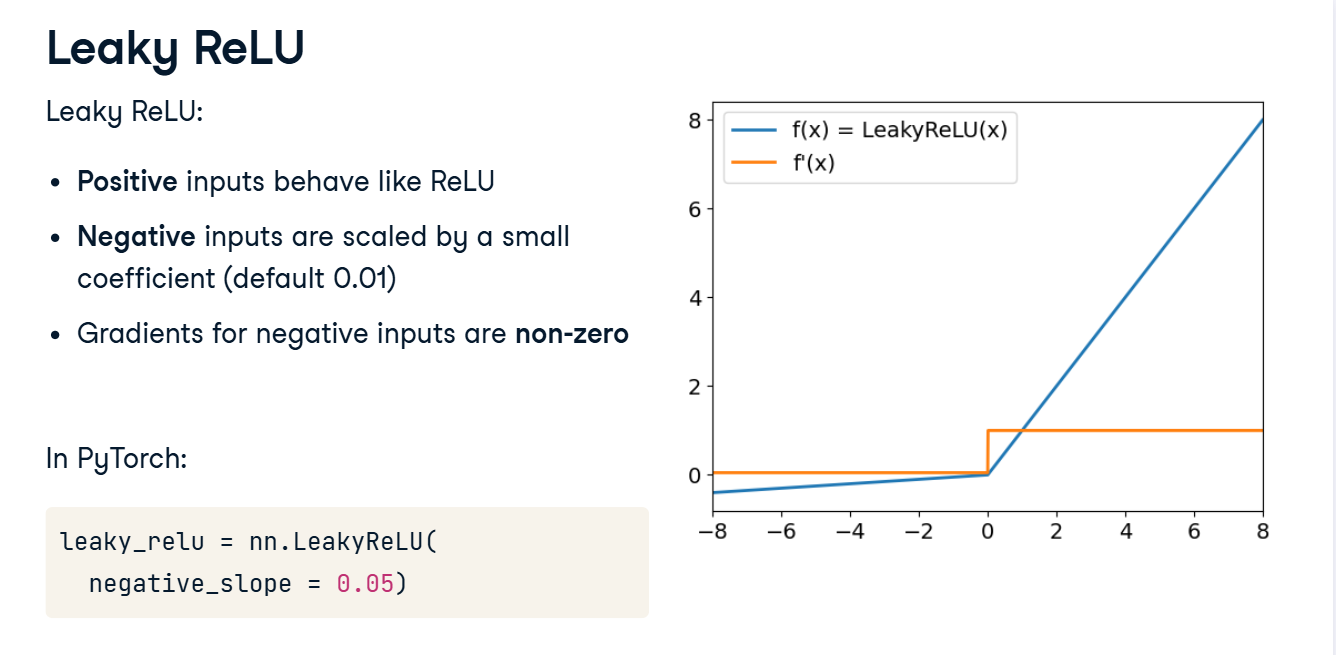

In [114]:
import torch
import torch.nn as nn

x = torch.tensor([-4., -2., -1., 0., 1., 3.])

relu = nn.ReLU()
leaky = nn.LeakyReLU(negative_slope=0.1)

relu_output = relu(x)
leaky_output = leaky(x)

print(f"Input       : {x}")
print(f"ReLU        : {relu_output}")
print(f"Leaky ReLU  : {leaky_output}")

model_relu = nn.Sequential(
    nn.Linear(6, 4),
    nn.ReLU(),
    nn.Linear(4, 2)
)

model_leaky = nn.Sequential(
    nn.Linear(6, 4),
    nn.LeakyReLU(negative_slope=0.1),
    nn.Linear(4, 2)
)

print(f"\nModel with ReLU:\n{model_relu}")
print(f"\nModel with Leaky ReLU:\n{model_leaky}")

Input       : tensor([-4., -2., -1.,  0.,  1.,  3.])
ReLU        : tensor([0., 0., 0., 0., 1., 3.])
Leaky ReLU  : tensor([-0.4000, -0.2000, -0.1000,  0.0000,  1.0000,  3.0000])

Model with ReLU:
Sequential(
  (0): Linear(in_features=6, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=2, bias=True)
)

Model with Leaky ReLU:
Sequential(
  (0): Linear(in_features=6, out_features=4, bias=True)
  (1): LeakyReLU(negative_slope=0.1)
  (2): Linear(in_features=4, out_features=2, bias=True)
)


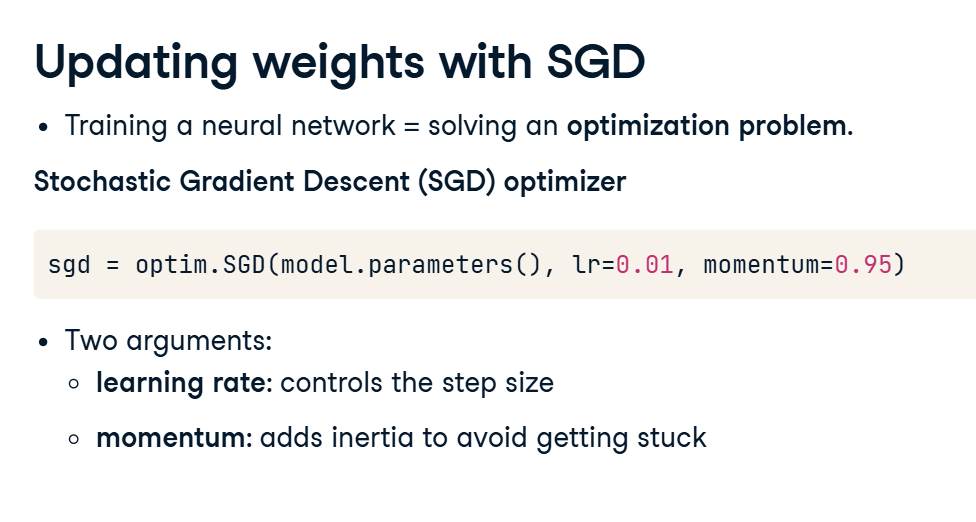

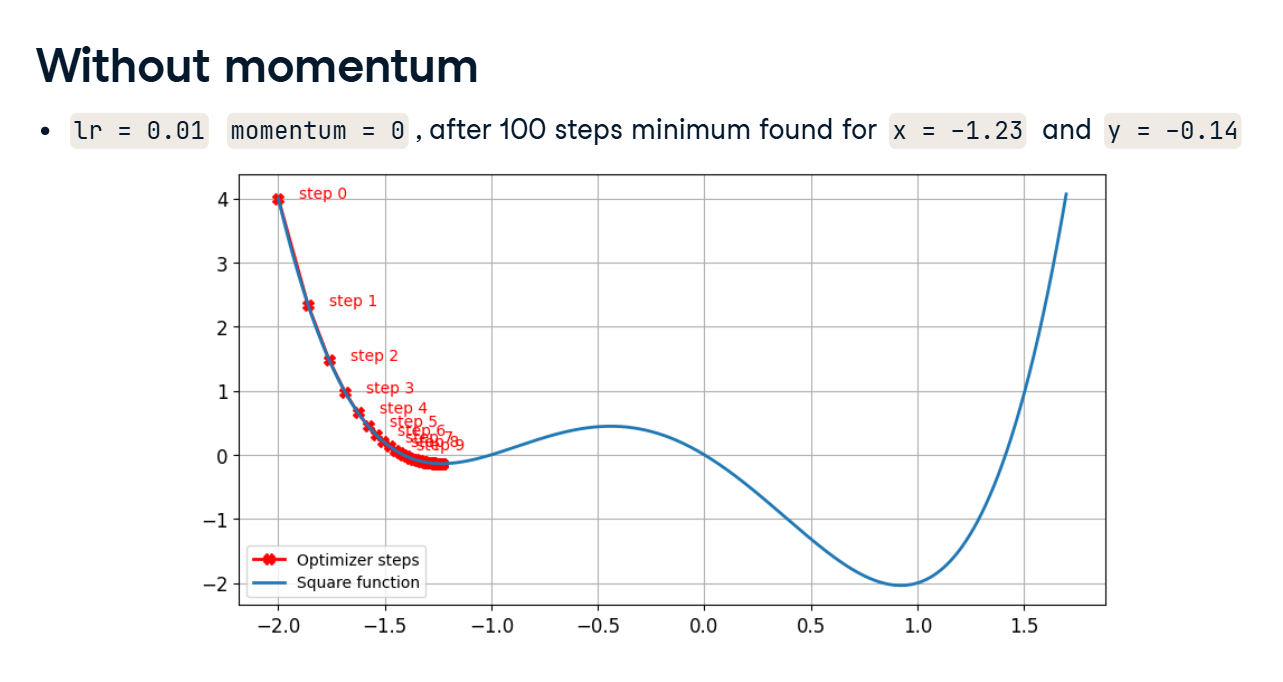

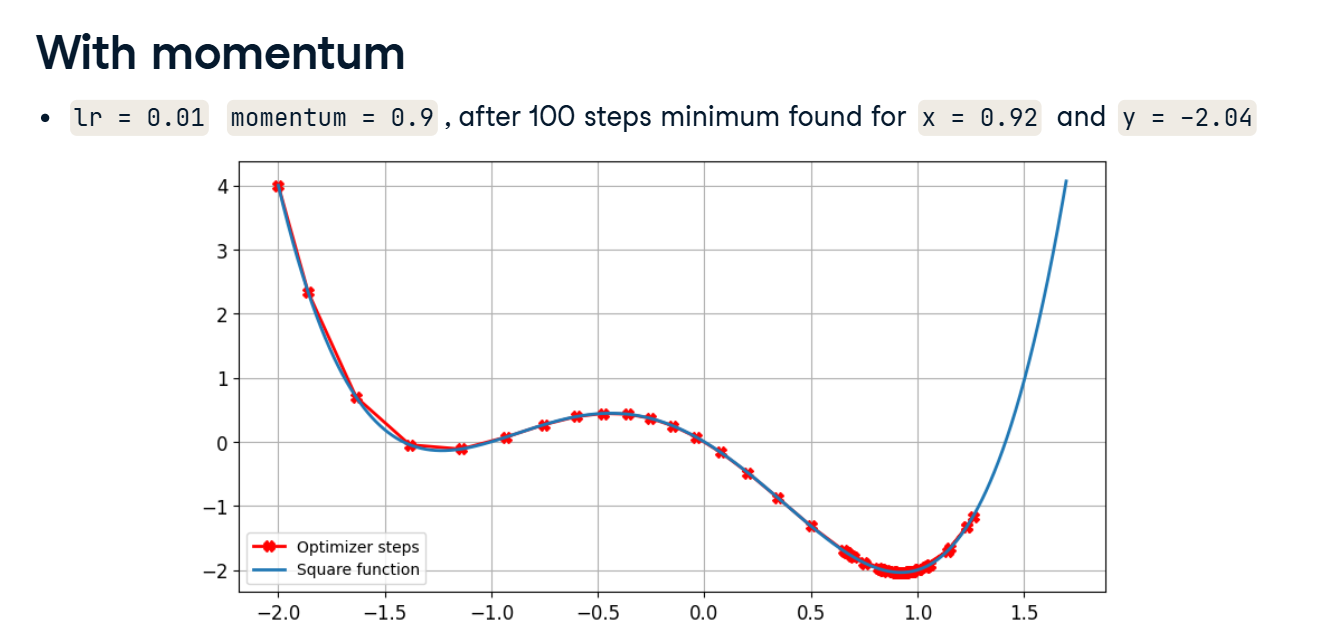

In [115]:
import torch
import torch.nn as nn
import torch.optim as optim

x = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
y = torch.tensor([[2.0], [4.0], [6.0], [8.0]])

model = nn.Linear(1, 1)

criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

for epoch in range(5):
    y_pred = model(x)
    loss = criterion(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss = {loss.item():.4f}")

Epoch 1, Loss = 45.8443
Epoch 2, Loss = 31.9173
Epoch 3, Loss = 13.7905
Epoch 4, Loss = 2.0267
Epoch 5, Loss = 1.4433


# LAYER INITIALIZATION AND TRANSFER LEARNING


In [116]:
# A layer weights are initialized to small values
# keeping both input data and layer weight small ensures stable outputs
import torch.nn as nn

layer = nn.Linear(64,128)
nn.init.uniform_(layer.weight)  # uniform distribution
print(layer.weight.min(), layer.weight.max())


tensor(0.0002, grad_fn=<MinBackward1>) tensor(0.9999, grad_fn=<MaxBackward1>)


In [117]:
# TRANSFER LEARNING
"""
Reusing a model trained on a first task for a second similar task
trained a model on dataset-A
use it's weights to train on dataset-B

"""
"""
import torch
layer = nn.Linear(64,128)
torch.save(layer,"layer.path")
new_layer = torch.load("layer.path")
"""

'\nimport torch\nlayer = nn.Linear(64,128)\ntorch.save(layer,"layer.path")\nnew_layer = torch.load("layer.path")\n'

In [118]:
# fine tuning is a type of transfer learning
# smaller learning rate
# train part of the network (we freeze some of them)
# rule of thumb- freeze early layers of network and fine-tune those closer to output

import torch.nn as nn

model = nn.Sequential(nn.Linear(64,128),nn.Linear(128,256))

for name,param in model.named_parameters():
  if name == '0.weight':    # freeze first layer
    param.requires_grad = False

In [119]:
layer0 = nn.Linear(16, 32)
layer1 = nn.Linear(32, 64)

# Use uniform initialization for layer0 and layer1 weights
nn.init.uniform_(layer0.weight)
nn.init.uniform_(layer1.weight)

model = nn.Sequential(layer0, layer1)

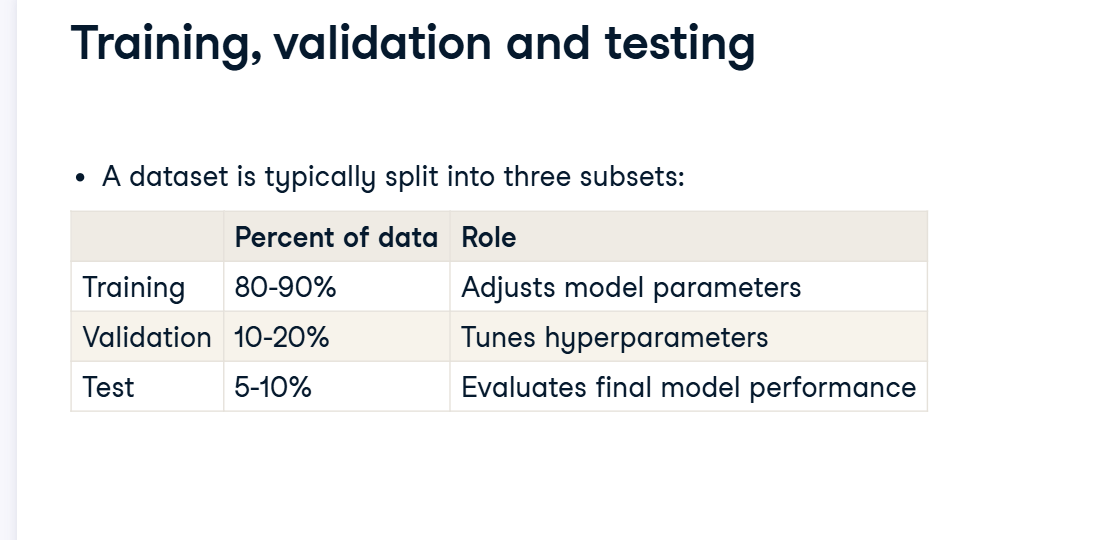

In [ ]:
# track loss and accuracy during training and validation
# compute loss accross all batches and epochs
training_loss = 0.0
for input,labels in trainloader:
  output=model(inputs) # run the forward pass
  loss = criterion(outputs,labels) # compute loss
  #back propagation
  loss.gradients() #compute gradients
  optimizer.step() # update weights
  optimizer.zero_grad() #reset

  training_loss += loss.item()
epochloss = training_loss / len(trainloader)


In [ ]:
"""
Validation loss is the loss (error) calculated on a validation dataset, which is data that the model has not seen during training.

"""
validation_loss = 0.0

model.eval()  # Put model in evaluation mode

with torch.no_grad():  # Disable gradients for efficiency
    for inputs, labels in validationloader:

        # Run the forward pass
        outputs = model(inputs)

        # Calculate the loss
        loss = criterion(outputs, labels)

        validation_loss += loss.item()

epoch_loss = validation_loss / len(validationloader)  # Compute mean loss

model.train()  # Switch back to training mode

In [ ]:
"""
torchmetrics is a PyTorch library used to compute
evaluation metrics for machine learning models.
 It automatically accumulates results across batches
and works well with PyTorch training loops.

"""
import torchmetrics

# create accuracy metric
metric = torchmetrics.Accuracy(task="multiclass",num_classes=3)

for feature,labels in dataloader:
  output = model(features)
  # compute batch accuracy (keeping argmax for one-hot labels)
  metric.update(output,labels.argmax(dim=-1))

# compute accuracy in whole epoch and reset
accuracy = metric.compute()
metric.reset()


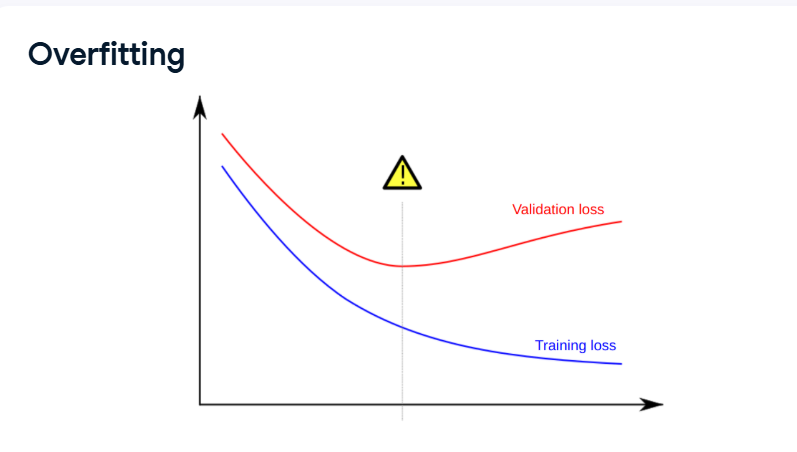

In [129]:
# overfitting
"""
the model does not generalize to see unseen data
model memorizes training data
performs well on training data but poorly on validation data

dataset is not large enough - use data augmentation
model has too much capacity - add dropout/reduce model size
weights are too large - weight decay

"""

# reugularization using a dropout layer
# randomly zeroes out elemenets of the i/p tensor during training
import torch, torch.nn as nn
model = nn.Sequential(
    nn.Linear(in_features=8,out_features=4),
    nn.ReLU(),
    nn.Dropout(p=0.5)  # p is probability of  dropping each neuron during training
)
features = torch.randn((1,8))
print(model(features))
# dropout is added after the activation function
# behaves differently in training vs evaluation
"""
use model.train() for training and model.eval() to
disable dropout during evaluation

"""

tensor([[0.7101, 0.0000, 0.3522, 0.0000]], grad_fn=<MulBackward0>)


'\nuse model.train() for training and model.eval() to\ndisable dropout during evaluation\n\n'

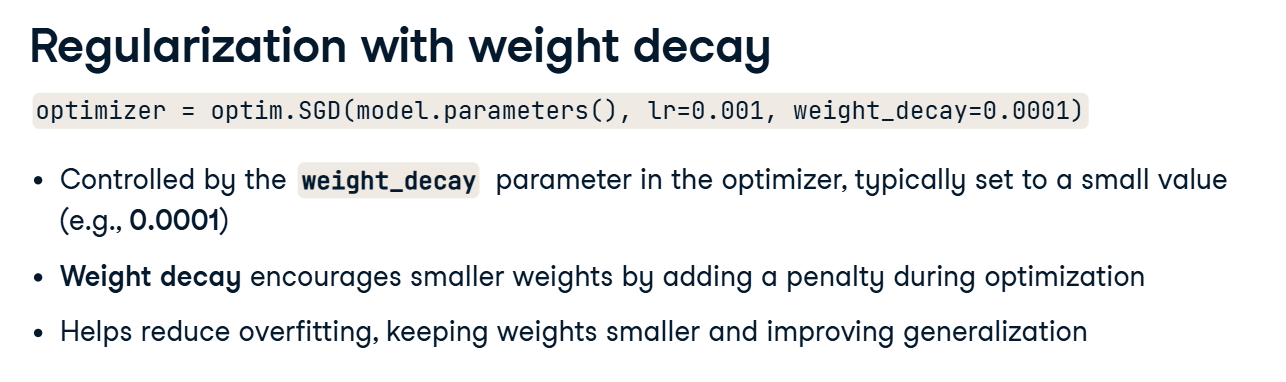

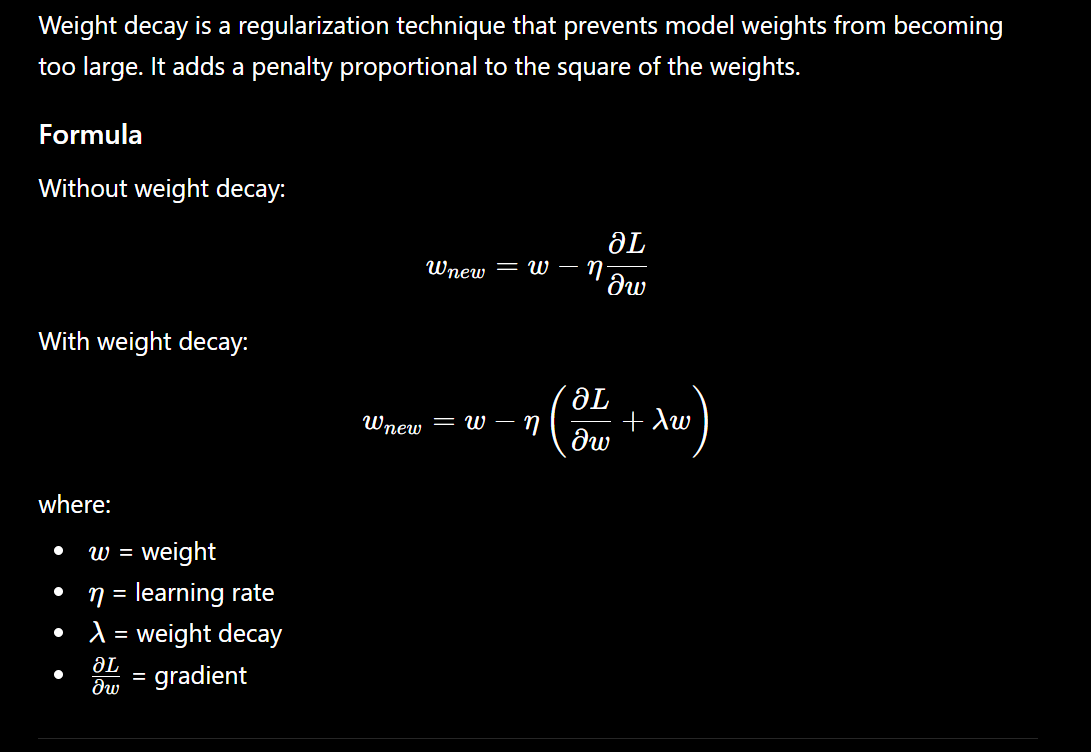

In [128]:
import torch
import torch.nn as nn
import torch.optim as optim

model = nn.Linear(2, 1)

optimizer = optim.SGD(model.parameters(),lr=0.01,weight_decay=0.001)

x = torch.tensor([[1.0, 2.0]])
y = torch.tensor([[3.0]])

criterion = nn.MSELoss()

optimizer.zero_grad()

pred = model(x)

loss = criterion(pred, y)

loss.backward()

optimizer.step()

# improving model performance
can we solve the problem?
set a performance baseline
increase performance on the validation set
acheieve the best possibe performance

In [127]:
# step 1 overfit the training dataset
# modify the training loop to overfit a single data point
features,labels = next(iter(dataloader))
for i in range(1000):
  outputs = model(features)
  loss = criterion(outputs,labels)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
# should reach 1.0 accuracy and 0 loss
# then scale up the entire training dataset
# keep default hyperparameters
"""
A hyperparameter is a value that you set before training a machine learning or deep learning model. It controls how the model learns,
 rather than being learned from the data.

In contrast, parameters (such as weights and biases) are learned automatically during training.

eg lr, batchsize,epochs

"""

'\nA hyperparameter is a value that you set before training a machine learning or deep learning model. It controls how the model learns,\n rather than being learned from the data.\n\nIn contrast, parameters (such as weights and biases) are learned automatically during training.\n\neg lr, batchsize,epochs\n\n'

In [126]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

x = torch.randn(100, 2)
y = torch.randn(100, 1)

dataset = TensorDataset(x, y)
dataloader = DataLoader(dataset,batch_size=10,shuffle=True)

model = nn.Sequential(
    nn.Linear(2, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)

criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(),lr=0.01)
features, labels = next(iter(dataloader))

for i in range(1000):
    outputs = model(features)
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (i + 1) % 100 == 0:
        print(f"Iteration {i+1}, Loss = {loss.item():.4f}")

Iteration 100, Loss = 0.3036
Iteration 200, Loss = 0.2399
Iteration 300, Loss = 0.2027
Iteration 400, Loss = 0.1726
Iteration 500, Loss = 0.1488
Iteration 600, Loss = 0.1293
Iteration 700, Loss = 0.1126
Iteration 800, Loss = 0.0979
Iteration 900, Loss = 0.0847
Iteration 1000, Loss = 0.0729


In [125]:
# step2 reduce overfitting   by adding dropout or weight decay

"""
model = nn.Sequential(nn.Linear(2, 8),nn.ReLU(),nn.Dropout(p=0.5),nn.Linear(8, 1))
or
optimizer = torch.optim.SGD(model.parameters(),lr=0.01,weight_decay=0.001)

"""

# step 3 - finetune hyperparameters
learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [16, 32, 64]
weight_decays = [0.0, 0.0001]
# iterate over these

"""
 Grid Search
Grid Search tries every possible combination of the hyperparameters.

Random Search
Random Search does not try every combination.
Instead, it randomly selects a few combinations from the search space.

"""

'\n Grid Search\nGrid Search tries every possible combination of the hyperparameters.\n\nRandom Search\nRandom Search does not try every combination.\nInstead, it randomly selects a few combinations from the search space.\n\n'

In [124]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset,DataLoader

x=torch.randn(100,10)
y=torch.randn(100,1)
dataset=TensorDataset(x,y)

learning_rates=[0.1,0.01]
batch_sizes=[16,32]
weight_decays=[0.0,0.001]

criterion=nn.MSELoss()

for lr in learning_rates:
    for batch_size in batch_sizes:
        for wd in weight_decays:
            dataloader=DataLoader(dataset,batch_size=batch_size,shuffle=True)
            model=nn.Sequential(nn.Linear(10,16),nn.ReLU(),nn.Linear(16,1))
            optimizer=optim.SGD(model.parameters(),lr=lr,weight_decay=wd)
            for epoch in range(5):
                for features,labels in dataloader:
                    outputs=model(features)
                    loss=criterion(outputs,labels)
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
            print(f"lr={lr}, batch_size={batch_size}, weight_decay={wd}, loss={loss.item():.4f}")

lr=0.1, batch_size=16, weight_decay=0.0, loss=0.6937
lr=0.1, batch_size=16, weight_decay=0.001, loss=1.2726
lr=0.1, batch_size=32, weight_decay=0.0, loss=0.6566
lr=0.1, batch_size=32, weight_decay=0.001, loss=0.8823
lr=0.01, batch_size=16, weight_decay=0.0, loss=0.9920
lr=0.01, batch_size=16, weight_decay=0.001, loss=0.4052
lr=0.01, batch_size=32, weight_decay=0.0, loss=0.5457
lr=0.01, batch_size=32, weight_decay=0.001, loss=1.0046


In [123]:
# template for grid search
import torch
import torch.nn as nn
import torch.optim as optim

learning_rates=[0.1,0.01]
batch_sizes=[16,32]
weight_decays=[0,0.001]

for lr in learning_rates:
    for batch_size in batch_sizes:
        for wd in weight_decays:
            print(f"lr={lr}, batch_size={batch_size}, weight_decay={wd}")

lr=0.1, batch_size=16, weight_decay=0
lr=0.1, batch_size=16, weight_decay=0.001
lr=0.1, batch_size=32, weight_decay=0
lr=0.1, batch_size=32, weight_decay=0.001
lr=0.01, batch_size=16, weight_decay=0
lr=0.01, batch_size=16, weight_decay=0.001
lr=0.01, batch_size=32, weight_decay=0
lr=0.01, batch_size=32, weight_decay=0.001


In [122]:
# template for random search
import numpy as np  # or import random also works

learning_rates=[0.1,0.01,0.001]
batch_sizes=[16,32,64]
weight_decays=[0,0.0001,0.001]

for i in range(5):
    lr=float(np.random.choice(learning_rates))
    batch_size=int(np.random.choice(batch_sizes))
    wd=float(np.random.choice(weight_decays))

    print(f"lr={lr}, batch_size={batch_size}, weight_decay={wd}")

lr=0.001, batch_size=32, weight_decay=0.0
lr=0.001, batch_size=16, weight_decay=0.0001
lr=0.001, batch_size=64, weight_decay=0.0
lr=0.01, batch_size=16, weight_decay=0.0001
lr=0.1, batch_size=64, weight_decay=0.001


In [121]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import TensorDataset,DataLoader

x=torch.randn(100,10)
y=torch.randn(100,1)

dataset=TensorDataset(x,y)

learning_rates=[0.1,0.01,0.001]
batch_sizes=[16,32,64]
weight_decays=[0,0.0001,0.001]

criterion=nn.MSELoss()

best_loss=float("inf")
best_params=None

for i in range(5):

    lr=float(np.random.choice(learning_rates))
    batch_size=int(np.random.choice(batch_sizes))
    wd=float(np.random.choice(weight_decays))

    dataloader=DataLoader(dataset,batch_size=batch_size,shuffle=True)

    model=nn.Sequential(nn.Linear(10,16),nn.ReLU(),nn.Linear(16,1))

    optimizer=optim.SGD(model.parameters(),lr=lr,weight_decay=wd)

    for epoch in range(5):
        for features,labels in dataloader:
            outputs=model(features)
            loss=criterion(outputs,labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    print(f"Trial {i+1}: lr={lr}, batch_size={batch_size}, weight_decay={wd}, loss={loss.item():.4f}")

    if loss.item()<best_loss:
        best_loss=loss.item()
        best_params=(lr,batch_size,wd)

print(f"\nBest Hyperparameters:")
print(f"Learning Rate = {best_params[0]}")
print(f"Batch Size = {best_params[1]}")
print(f"Weight Decay = {best_params[2]}")
print(f"Best Loss = {best_loss:.4f}")

print(type(np.random.choice(batch_sizes))) # pytorch looks for python int so int() is used

Trial 1: lr=0.1, batch_size=32, weight_decay=0.001, loss=0.6605
Trial 2: lr=0.01, batch_size=32, weight_decay=0.001, loss=0.8263
Trial 3: lr=0.01, batch_size=32, weight_decay=0.001, loss=1.0200
Trial 4: lr=0.001, batch_size=16, weight_decay=0.0, loss=1.3895
Trial 5: lr=0.01, batch_size=16, weight_decay=0.0, loss=0.2876

Best Hyperparameters:
Learning Rate = 0.01
Batch Size = 16
Weight Decay = 0.0
Best Loss = 0.2876
<class 'numpy.int64'>


In [133]:
import numpy as np

values = []

for idx in range(10):
    factor = np.random.uniform(2, 4)
    lr = 10 ** -factor

    momentum = np.random.uniform(0.85, 0.99)

    values.append((lr, momentum))

# plot_hyperparameter_search(values)

This code is performing Random Search for hyperparameter tuning. It randomly generates 10 different combinations of learning rate and momentum.

np.random.uniform(2, 4) randomly chooses a decimal value between 2 and 4.
10 ** -factor gives a learning rate between 0.01 (10⁻²) and 0.0001 (10⁻⁴).
np.random.uniform(0.85, 0.99) randomly chooses a momentum between 0.85 and 0.99.

# the end .........